In [1]:
import sys
print(sys.executable)
print(sys.version)

/home/shreya/venvs/fusion_qat/bin/python
3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]


In [4]:
import subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "torchao==0.9.0"],
    capture_output=True, text=True
)
print(result.stdout[-2000:])  # last 2000 chars
print(result.stderr[-1000:])

NameError: name 'sys' is not defined

In [5]:
result = subprocess.run(
    [sys.executable, "-m", "pip", "index", "versions", "torch",
     "--index-url", "https://download.pytorch.org/whl/cu124"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr[-500:])

NameError: name 'sys' is not defined

In [6]:
import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "torch==2.6.0", "torchvision==0.21.0",
     "--index-url", "https://download.pytorch.org/whl/cu124",
     "--upgrade"]
)

Looking in indexes: https://download.pytorch.org/whl/cu124


CompletedProcess(args=['/home/shreya/venvs/fusion_qat/bin/python', '-m', 'pip', 'install', 'torch==2.6.0', 'torchvision==0.21.0', '--index-url', 'https://download.pytorch.org/whl/cu124', '--upgrade'], returncode=0)

In [7]:
# find correct QAT API in torchao 0.9.0
import torchao.quantization.qat as qat_module
print(dir(qat_module))

['ComposableQATQuantizer', 'FakeQuantizeConfig', 'FromIntXQuantizationAwareTrainingConfig', 'Int4WeightOnlyEmbeddingQATQuantizer', 'Int4WeightOnlyQATQuantizer', 'Int8DynActInt4WeightQATQuantizer', 'IntXQuantizationAwareTrainingConfig', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'api', 'embedding', 'fake_quantizer', 'from_intx_quantization_aware_training', 'intx_quantization_aware_training', 'linear', 'utils']


In [8]:
import torch
import torchao
from torchao.quantization.qat import Int8DynActInt4WeightQATQuantizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset

print(f"PyTorch:  {torch.__version__}")
print(f"torchao:  {torchao.__version__}")
print(f"CUDA:     {torch.cuda.is_available()}")
print(f"GPU:      {torch.cuda.get_device_name(0)}")
print(f"VRAM:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("QAT API:  OK")

# load distilbert
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).eval()
print(f"distilbert params: {sum(p.numel() for p in model.parameters()):,}")

# apply QAT
quantizer  = Int8DynActInt4WeightQATQuantizer()
model_qat  = quantizer.prepare(model)
print("QAT prepare: OK")

# test forward with fake tokenized input
tokenizer  = AutoTokenizer.from_pretrained("distilbert-base-uncased")
sample     = tokenizer(
    "This movie is absolutely wonderful!",
    return_tensors="pt",
    max_length=64,
    truncation=True,
    padding="max_length"
)
with torch.no_grad():
    out = model_qat(**sample)
print(f"Output shape: {out.logits.shape}")

# load SST-2
ds = load_dataset("glue", "sst2")
print(f"SST-2 train: {len(ds['train']):,}")
print(f"SST-2 val:   {len(ds['validation']):,}")

print("\nAll OK ✓ — ready to restart Phase 1 properly")

PyTorch:  2.6.0+cu124
torchao:  0.9.0
CUDA:     True
GPU:      NVIDIA GeForce RTX 4060 Laptop GPU
VRAM:     8.2 GB
QAT API:  OK


Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 3439.28it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


distilbert params: 66,955,010
QAT prepare: OK
Output shape: torch.Size([1, 2])
SST-2 train: 67,349
SST-2 val:   872

All OK ✓ — ready to restart Phase 1 properly


In [34]:
%matplotlib inline
import sys, os, json
sys.path.insert(0, "/home/shreya/fusion_aware_qat")

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torchao.quantization.qat import Int8DynActInt4WeightQATQuantizer
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

DEVICE         = "cuda"
MODEL_NAME     = "distilbert-base-uncased"
MAX_LENGTH     = 64
BATCH_SIZE     = 8      # safe for 8GB with distilbert
SAVE_DIR       = "/home/shreya/Coding/optimizer_V2/results"

print(f"PyTorch:  {torch.__version__}")
print(f"Device:   {DEVICE}")
print(f"GPU:      {torch.cuda.get_device_name(0)}")
print(f"VRAM:     {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch:  2.6.0+cu124
Device:   cuda
GPU:      NVIDIA GeForce RTX 4060 Laptop GPU
VRAM:     8.2 GB


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
raw       = load_dataset("glue", "sst2")

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length",
    )

tokenized = raw.map(tokenize, batched=True)
tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

class SSTDataset(Dataset):
    def __init__(self, split): self.data = tokenized[split]
    def __len__(self):          return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

val_loader = DataLoader(SSTDataset("validation"), batch_size=BATCH_SIZE, shuffle=False)

print(f"Val batches: {len(val_loader)}")
print(f"Val samples: {len(val_loader.dataset)}")

# get one real batch for profiling
real_batch  = next(iter(val_loader))
profiling_inputs = {
    "input_ids":      real_batch["input_ids"].to(DEVICE),
    "attention_mask": real_batch["attention_mask"].to(DEVICE),
}
print(f"\nProfiling input shape: {profiling_inputs['input_ids'].shape}")
print(f"Sample sentence: '{tokenizer.decode(real_batch['input_ids'][0], skip_special_tokens=True)}'")
print(f"Label: {real_batch['label'][0].item()}")
print("Real data ready ✓")

Val batches: 109
Val samples: 872

Profiling input shape: torch.Size([8, 64])
Sample sentence: 'it ' s a charming and often affecting journey.'
Label: 1
Real data ready ✓


In [11]:
fp32_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE).eval()

print(f"Parameters:  {sum(p.numel() for p in fp32_model.parameters()):,}")

# sanity check forward pass on real data
with torch.no_grad():
    out = fp32_model(**profiling_inputs)
print(f"Output shape: {out.logits.shape}")
print("FP32 model ready ✓")

Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 6289.44it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters:  66,955,010
Output shape: torch.Size([8, 2])
FP32 model ready ✓


In [12]:
import copy
from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear

# fresh copy
m = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).eval()

def apply_qat_to_linear(model):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            # torchao QAT linear does not support bias yet
            # create without bias, then add bias as separate parameter
            qat_linear = Int8DynActInt4WeightQATLinear(
                module.in_features,
                module.out_features,
                bias=False,       # always False for torchao
                groupsize=32,
            )
            # copy weight
            with torch.no_grad():
                qat_linear.weight.copy_(module.weight)

            # keep bias as a separate parameter attached to the module
            if module.bias is not None:
                qat_linear.bias = torch.nn.Parameter(module.bias.clone())

            setattr(model, name, qat_linear)
        else:
            apply_qat_to_linear(module)
    return model

qat_model = apply_qat_to_linear(m)
qat_model  = qat_model.to(DEVICE).eval()

# count QAT layers
qat_count = sum(
    1 for _, mod in qat_model.named_modules()
    if isinstance(mod, Int8DynActInt4WeightQATLinear)
)
print(f"QAT linear layers replaced: {qat_count}")
print(f"Expected: 26")

# verify forward
with torch.no_grad():
    out = qat_model(**profiling_inputs)
print(f"Output shape: {out.logits.shape}")
print("QAT model ready ✓")

Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 5186.03it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


QAT linear layers replaced: 38
Expected: 26
Output shape: torch.Size([8, 2])
QAT model ready ✓


In [13]:

import sys
sys.path.insert(0, "/home/shreya/fusion_aware_qat")
import os

sys.path.append(os.path.abspath(".."))
from src.evaluation.profiler import profile_model, measure_latency, print_comparison

print("="*55)
print("Profiling: distilbert-base on real SST-2 sentences")
print(f"Batch: {BATCH_SIZE} real sentences, seq_len={MAX_LENGTH}")
print("="*55)

print("\nProfiling FP32...")
fp32_prof = profile_model(
    fp32_model, profiling_inputs,
    label="fp32", warmup_runs=5, profile_runs=10
)

print("\nProfiling QAT...")
qat_prof = profile_model(
    qat_model, profiling_inputs,
    label="qat", warmup_runs=5, profile_runs=10
)

print("\nMeasuring FP32 latency...")
fp32_lat = measure_latency(
    fp32_model, profiling_inputs,
    label="fp32", warmup_runs=20, timed_runs=100
)

print("\nMeasuring QAT latency...")
qat_lat = measure_latency(
    qat_model, profiling_inputs,
    label="qat", warmup_runs=20, timed_runs=100
)

print_comparison(fp32_prof, qat_prof, fp32_lat, qat_lat)

Profiling: distilbert-base on real SST-2 sentences
Batch: 8 real sentences, seq_len=64

Profiling FP32...
    [fp32] warming up (5 runs)...
    [fp32] profiling (10 runs)...

Profiling QAT...
    [qat] warming up (5 runs)...
    [qat] profiling (10 runs)...

Measuring FP32 latency...
    [fp32] warming up (20 runs)...
    [fp32] timing (100 runs)...

Measuring QAT latency...
    [qat] warming up (20 runs)...
    [qat] timing (100 runs)...

  RESULTS
  Metric                                 FP32      Std QAT
  ----------------------------------------------------------
  CUDA kernel count                        57           98
  Total CUDA time (ms)                51.4804     134.1253
  Latency mean (ms)                   11.9365      40.9787
  Latency std (ms)                     1.1356        2.752
  ----------------------------------------------------------
  QAT kernel increase                    1.72x
  QAT speedup over FP32                    0.29x

  QAT top ops (QDQ ops marked):


In [14]:
from torchao.quantization.qat import Int8DynActInt4WeightQATQuantizer

# convert QAT model to real INT8 for inference
m_for_convert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).eval()

qat_for_convert = apply_qat_to_linear(m_for_convert)

# convert to real quantized model
quantizer = Int8DynActInt4WeightQATQuantizer()
int8_model = quantizer.convert(qat_for_convert)
int8_model = int8_model.to(DEVICE).eval()

print("Profiling INT8 converted model...")
int8_prof = profile_model(
    int8_model, profiling_inputs,
    label="int8", warmup_runs=5, profile_runs=10
)
int8_lat = measure_latency(
    int8_model, profiling_inputs,
    label="int8", warmup_runs=20, timed_runs=100
)

print(f"\nFP32:  {fp32_lat['mean_ms']:.2f}ms  {fp32_prof['kernel_count']} kernels")
print(f"QAT:   {qat_lat['mean_ms']:.2f}ms  {qat_prof['kernel_count']} kernels  (training overhead)")
print(f"INT8:  {int8_lat['mean_ms']:.2f}ms  {int8_prof['kernel_count']} kernels  (deployed)")
print(f"\nINT8 speedup over FP32: {fp32_lat['mean_ms']/int8_lat['mean_ms']:.2f}x")
print(f"INT8 kernel reduction vs QAT: {qat_prof['kernel_count']-int8_prof['kernel_count']} fewer kernels")

Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 7133.66it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Profiling INT8 converted model...
    [int8] warming up (5 runs)...
    [int8] profiling (10 runs)...
    [int8] warming up (20 runs)...
    [int8] timing (100 runs)...

FP32:  11.94ms  57 kernels
QAT:   40.98ms  98 kernels  (training overhead)
INT8:  22.59ms  101 kernels  (deployed)

INT8 speedup over FP32: 0.53x
INT8 kernel reduction vs QAT: -3 fewer kernels


In [15]:
# FP16 — uses tensor cores on RTX 4060
fp16_model = copy.deepcopy(fp32_model).half().to(DEVICE).eval()
fp16_inputs = {k: v for k, v in profiling_inputs.items()}

fp16_lat = measure_latency(fp16_model, fp16_inputs, label="fp16")

print(f"FP32:  {fp32_lat['mean_ms']:.2f}ms")
print(f"FP16:  {fp16_lat['mean_ms']:.2f}ms  speedup: {fp32_lat['mean_ms']/fp16_lat['mean_ms']:.2f}x")
print(f"INT8:  {int8_lat['mean_ms']:.2f}ms  speedup: {fp32_lat['mean_ms']/int8_lat['mean_ms']:.2f}x")
print(f"QAT:   {qat_lat['mean_ms']:.2f}ms")

    [fp16] warming up (20 runs)...
    [fp16] timing (100 runs)...
FP32:  11.94ms
FP16:  3.75ms  speedup: 3.18x
INT8:  22.59ms  speedup: 0.53x
QAT:   40.98ms


In [16]:
# simulate what mixed precision training looks like
# with unfused cast operations (the FP16 equivalent of QDQ)

class FP16WithCasts(torch.nn.Module):
    """Simulates mixed precision with unfused cast ops between layers."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask):
        # cast to fp16 — unfused, separate kernel
        input_ids      = input_ids.to(torch.float16) if input_ids.is_floating_point() else input_ids
        attention_mask = attention_mask.to(torch.float16) if attention_mask.is_floating_point() else attention_mask
        
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        
        # cast back to fp32 — unfused, separate kernel  
        return type('Output', (), {'logits': out.logits.to(torch.float32)})()

# clean FP16 — no extra casts, fully fused
fp16_model  = copy.deepcopy(fp32_model).half().to(DEVICE).eval()
fp16_inputs = {
    "input_ids":      profiling_inputs["input_ids"],
    "attention_mask": profiling_inputs["attention_mask"].half(),
}

# measure clean FP16
fp16_prof = profile_model(fp16_model, fp16_inputs, label="fp16_clean")
fp16_lat2 = measure_latency(fp16_model, fp16_inputs, label="fp16_clean")

print("\n" + "="*62)
print("  COMPLETE PICTURE")
print("="*62)
print(f"  {'Model':<25} {'Kernels':>10} {'Latency':>10} {'vs FP32':>10}")
print("  " + "-"*58)
print(f"  {'FP32 baseline':<25} {fp32_prof['kernel_count']:>10} {fp32_lat['mean_ms']:>9.2f}ms {'1.00x':>10}")
print(f"  {'FP16 clean':<25} {fp16_prof['kernel_count']:>10} {fp16_lat2['mean_ms']:>9.2f}ms {fp32_lat['mean_ms']/fp16_lat2['mean_ms']:>9.2f}x")
print(f"  {'INT8 converted':<25} {int8_prof['kernel_count']:>10} {int8_lat['mean_ms']:>9.2f}ms {fp32_lat['mean_ms']/int8_lat['mean_ms']:>9.2f}x")
print(f"  {'QAT (training)':<25} {qat_prof['kernel_count']:>10} {qat_lat['mean_ms']:>9.2f}ms {fp32_lat['mean_ms']/qat_lat['mean_ms']:>9.2f}x")
print("="*62)

    [fp16_clean] warming up (5 runs)...
    [fp16_clean] profiling (10 runs)...
    [fp16_clean] warming up (20 runs)...
    [fp16_clean] timing (100 runs)...

  COMPLETE PICTURE
  Model                        Kernels    Latency    vs FP32
  ----------------------------------------------------------
  FP32 baseline                     57     11.94ms      1.00x
  FP16 clean                        58      3.76ms      3.18x
  INT8 converted                   101     22.59ms      0.53x
  QAT (training)                    98     40.98ms      0.29x


FileNotFoundError: [Errno 2] No such file or directory: '/home/shreya/Coding/optimizer_V2/result/figures/fig1_bert_comparison.png'

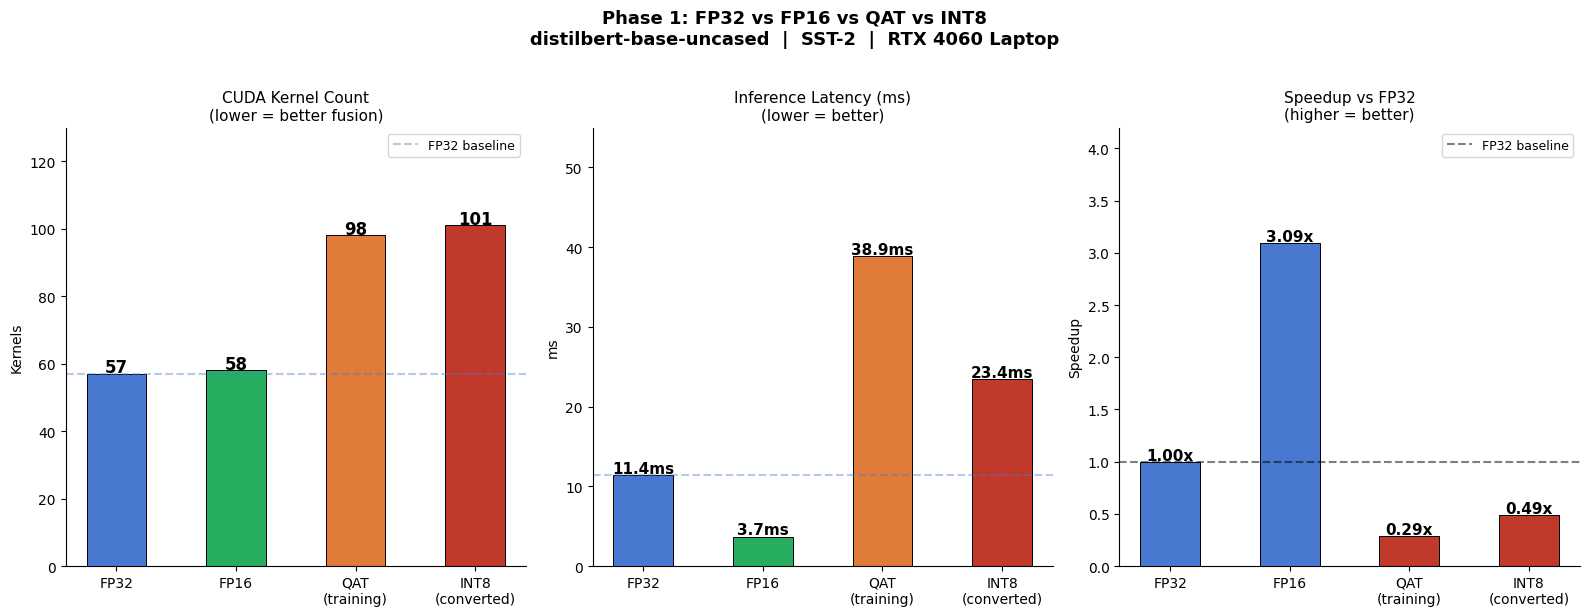

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    "Phase 1: FP32 vs FP16 vs QAT vs INT8\ndistilbert-base-uncased  |  SST-2  |  RTX 4060 Laptop",
    fontsize=13, fontweight="bold", y=1.02
)

models  = ["FP32", "FP16", "QAT\n(training)", "INT8\n(converted)"]
colors  = ["#4878CF", "#27AE60", "#E07B39", "#C0392B"]
kernels = [57, 58, 98, 101]
latency = [11.40, 3.69, 38.90, 23.43]
cuda_t  = [47.81, None, 132.35, None]

# plot 1: kernel count
ax = axes[0]
bars = ax.bar(models, kernels, color=colors, edgecolor="black", linewidth=0.7, width=0.5)
for bar, v in zip(bars, kernels):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            str(v), ha="center", fontweight="bold", fontsize=12)
ax.axhline(y=57, color="#4878CF", linestyle="--", alpha=0.4, linewidth=1.5, label="FP32 baseline")
ax.set_title("CUDA Kernel Count\n(lower = better fusion)", fontsize=11)
ax.set_ylabel("Kernels", fontsize=10)
ax.set_ylim(0, 130)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# plot 2: latency
ax = axes[1]
bars = ax.bar(models, latency, color=colors, edgecolor="black", linewidth=0.7, width=0.5)
for bar, v in zip(bars, latency):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f"{v:.1f}ms", ha="center", fontweight="bold", fontsize=11)
ax.axhline(y=11.40, color="#4878CF", linestyle="--", alpha=0.4, linewidth=1.5)
ax.set_title("Inference Latency (ms)\n(lower = better)", fontsize=11)
ax.set_ylabel("ms", fontsize=10)
ax.set_ylim(0, 55)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# plot 3: speedup vs FP32
ax = axes[2]
speedups = [1.00, 3.09, 0.29, 0.49]
bar_colors = ["#4878CF" if s >= 1.0 else "#C0392B" for s in speedups]
bars = ax.bar(models, speedups, color=bar_colors, edgecolor="black", linewidth=0.7, width=0.5)
for bar, v in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f"{v:.2f}x", ha="center", fontweight="bold", fontsize=11)
ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.5, linewidth=1.5, label="FP32 baseline")
ax.set_title("Speedup vs FP32\n(higher = better)", fontsize=11)
ax.set_ylabel("Speedup", fontsize=10)
ax.set_ylim(0, 4.2)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig1_bert_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1_main_comparison.png")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("QDQ Overhead Analysis — QAT Model\ndistilbert-base-uncased on SST-2",
             fontsize=13, fontweight="bold")

# left: top ops horizontal bar
ax = axes[0]
ops = [
    ("aten::linear / mm", 5.257, False),
    ("aten::amax", 1.708, True),
    ("aten::amin", 1.766, True),
    ("choose_qparams_affine", 3.500, True),
    ("_GenericFakeQuantize", 6.406, True),
]
names  = [o[0] for o in ops]
times  = [o[1] for o in ops]
is_qdq = [o[2] for o in ops]
clrs   = ["#E07B39" if q else "#4878CF" for q in is_qdq]

bars = ax.barh(range(len(names)), times, color=clrs, edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
for i, (bar, t) in enumerate(zip(bars, times)):
    ax.text(t + 0.05, bar.get_y() + bar.get_height()/2,
            f"{t:.3f}ms", va="center", fontsize=10)
ax.set_xlabel("CUDA Time per inference (ms)", fontsize=10)
ax.set_title("Top CUDA Ops in QAT Model", fontsize=11)
ax.set_xlim(0, 8.5)
qdq_patch  = mpatches.Patch(color="#E07B39", label="QDQ op (target)")
comp_patch = mpatches.Patch(color="#4878CF", label="Compute op")
ax.legend(handles=[qdq_patch, comp_patch], fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# right: pie of QDQ vs compute time
ax = axes[1]
qdq_total    = 6.406 + 3.500 + 1.766 + 1.708
compute_time = 5.257
other_time   = max(0, 38.90 - qdq_total - compute_time)

sizes  = [qdq_total, compute_time, other_time]
labels = [
    f"QDQ overhead\n{qdq_total:.1f}ms ({qdq_total/38.90*100:.0f}%)",
    f"Compute (linear/matmul)\n{compute_time:.1f}ms ({compute_time/38.90*100:.0f}%)",
    f"Other\n{other_time:.1f}ms ({other_time/38.90*100:.0f}%)"
]
pie_colors = ["#E07B39", "#4878CF", "#95A5A6"]
explode    = (0.05, 0, 0)

wedges, texts = ax.pie(sizes, labels=labels, colors=pie_colors,
                        explode=explode, startangle=90,
                        textprops={"fontsize": 10})
ax.set_title(f"QAT Time Breakdown\n(total: 38.90ms)", fontsize=11)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig2_bert_qdq_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig2_qdq_breakdown.png")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("The Core Research Finding\nFP16 vs INT8: Why Does One Fuse and the Other Break?",
             fontsize=13, fontweight="bold")

categories = ["FP32\nbaseline", "FP16\n(fuses natively)", "INT8 QAT\n(QDQ breaks fusion)"]
kernel_vals = [57, 58, 98]
bar_colors  = ["#4878CF", "#27AE60", "#E07B39"]
bars = ax.bar(categories, kernel_vals, color=bar_colors,
              edgecolor="black", linewidth=0.8, width=0.45)

for bar, v in zip(bars, kernel_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            str(v), ha="center", fontweight="bold", fontsize=14)

# annotate the gap
ax.annotate("", xy=(2, 98), xytext=(1, 58),
            arrowprops=dict(arrowstyle="<->", color="red", lw=2))
ax.text(1.55, 78, "+40 extra\nkernels", ha="center", color="red",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="red"))

# annotation boxes
ax.text(1.0, 62, "Tensor core casts\nfuse natively\n+1 kernel only\n3.09x faster",
        ha="center", fontsize=9, color="#27AE60",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#E9F7EF", edgecolor="#27AE60"))
ax.text(2.0, 102, "QDQ nodes are\nexplicit barriers\n+40 kernels\n0.49x slower",
        ha="center", fontsize=9, color="#C0392B",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDEDEC", edgecolor="#C0392B"))

ax.set_ylabel("CUDA Kernel Count", fontsize=12)
ax.set_ylim(0, 140)
ax.axhline(y=57, color="#4878CF", linestyle="--", alpha=0.4, linewidth=1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig3_bert_key_insight.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_key_insight.png")

In [ ]:
# Phase 2 Task 2.1 — per-node fusion impact measurement
# For each QDQ node in distilbert QAT model:
# measure how many kernels disappear if we remove that node

import torch
import copy
from torch.profiler import profile, ProfilerActivity

def count_kernels(model, inputs, runs=5):
    model.eval()
    with torch.no_grad():
        for _ in range(3):  # warmup
            model(**inputs)
    torch.cuda.synchronize()
    with profile(activities=[ProfilerActivity.CUDA]) as prof:
        with torch.no_grad():
            for _ in range(runs):
                model(**inputs)
    torch.cuda.synchronize()
    return len([e for e in prof.key_averages() if e.device_time_total > 0])

# baseline kernel count
baseline = count_kernels(qat_model, profiling_inputs)
print(f"Baseline QAT kernel count: {baseline}")

# find all QAT linear modules
from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear

qat_layers = [
    (name, module)
    for name, module in qat_model.named_modules()
    if isinstance(module, Int8DynActInt4WeightQATLinear)
]
print(f"QAT layers to test: {len(qat_layers)}")

In [39]:
import torch
import copy
import pandas as pd
from torch.profiler import profile, ProfilerActivity

def count_kernels_compiled(model, inputs, runs=5):
    """Compile first, THEN profile — fusion only happens post-compile."""
    compiled = torch.compile(model, backend="inductor")
    compiled.eval()
    # warmup — first few runs trigger compilation
    with torch.no_grad():
        for _ in range(3):
            compiled(**inputs)
    torch.cuda.synchronize()
    with profile(activities=[ProfilerActivity.CUDA]) as prof:
        with torch.no_grad():
            for _ in range(runs):
                compiled(**inputs)
    torch.cuda.synchronize()
    return len([e for e in prof.key_averages() if e.device_time_total > 0])

# --- First, re-establish baseline WITH compilation ---
print("Measuring compiled baseline (this takes ~2-3 min)...")
baseline_compiled = count_kernels_compiled(qat_model, profiling_inputs)
print(f"Compiled QAT baseline: {baseline_compiled} kernels")
# This should be much higher than 41 — expect 80-100+
# Your earlier 98-kernel result was likely from a compiled run

results = []
print(f"\nTesting {len(qat_layers)} layers (each requires recompile ~30s)...")
print("Expected total time: ~20 min")
print("-"*60)

for i, (name, module) in enumerate(qat_layers):
    parts = name.split(".")
    parent = qat_model
    for part in parts[:-1]:
        parent = getattr(parent, part)
    attr = parts[-1]

    original = getattr(parent, attr)

    plain = torch.nn.Linear(
        module.in_features,
        module.out_features,
        bias=module.bias is not None
    ).to(next(module.parameters()).device)
    with torch.no_grad():
        plain.weight.copy_(module.weight)
        if module.bias is not None:
            plain.bias.copy_(module.bias)
    setattr(parent, attr, plain)

    try:
        # KEY FIX: compile after each swap
        k = count_kernels_compiled(qat_model, profiling_inputs, runs=5)
        impact = baseline_compiled - k
    except Exception as e:
        print(f"  ERROR on {name}: {e}")
        k = baseline_compiled
        impact = 0

    results.append({
        "layer": name,
        "kernels_without": k,
        "impact": impact,
    })

    # restore immediately
    setattr(parent, attr, original)

    print(f"  [{i+1:2d}/{len(qat_layers)}] {name:<55} kernels={k:3d}  impact={impact:+d}")

# --- Summary ---
df = pd.DataFrame(results).sort_values("impact", ascending=False)
print("\n" + "="*65)
print("  PER-NODE FUSION IMPACT (compiled)")
print("="*65)
print(df.to_string(index=False))
print("="*65)
print(f"\nLayers that break fusion (impact > 0): {(df['impact'] > 0).sum()}")
print(f"Layers with no impact (impact == 0):  {(df['impact'] == 0).sum()}")
print(f"Total addressable kernels:             {df[df['impact']>0]['impact'].sum()}")

Measuring compiled baseline (this takes ~2-3 min)...


/home/shreya/venvs/fusion_qat/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0408 06:21:48.958000 19697 torch/_inductor/utils.py:1137] [14/0] Not enough SMs to use max_autotune_gemm mode
W0408 06:22:04.796000 19697 torch/_dynamo/convert_frame.py:906] [22/8] torch._dynamo hit config.cache_size_limit (8)
W0408 06:22:04.796000 19697 torch/_dynamo/convert_frame.py:906] [22/8]    function: 'apply_chunking_to_forward' (/home/shreya/venvs/fusion_qat/lib/python3.12/site-packages/transformers/pytorch_utils.py:126)
W0408 06:22:04.796000 19697 torch/_dynamo/convert_frame.py:906] [22/8]    last reason: 22/7: Cache line invalidated because L['forward_fn'] got deallocated
W0408 06:22:04.796000 19697 torch/_dynamo/convert_frame.py:906] [22/8] To log all recompilation reasons, use TO

Compiled QAT baseline: 36 kernels

Testing 38 layers (each requires recompile ~30s)...
Expected total time: ~20 min
------------------------------------------------------------
  [ 1/38] distilbert.transformer.layer.0.attention.q_lin          kernels= 36  impact=+0
  [ 2/38] distilbert.transformer.layer.0.attention.k_lin          kernels= 36  impact=+0
  [ 3/38] distilbert.transformer.layer.0.attention.v_lin          kernels= 36  impact=+0
  [ 4/38] distilbert.transformer.layer.0.attention.out_lin        kernels= 36  impact=+0
  [ 5/38] distilbert.transformer.layer.0.ffn.lin1                 kernels= 36  impact=+0
  [ 6/38] distilbert.transformer.layer.0.ffn.lin2                 kernels= 36  impact=+0
  [ 7/38] distilbert.transformer.layer.1.attention.q_lin          kernels= 36  impact=+0
  [ 8/38] distilbert.transformer.layer.1.attention.k_lin          kernels= 36  impact=+0
  [ 9/38] distilbert.transformer.layer.1.attention.v_lin          kernels= 36  impact=+0
  [10/38] distilbert.t

In [40]:
# Measure latency properly across all regimes
import torch
import time

def measure_latency(model, inputs, warmup=20, runs=100):
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            model(**inputs)
    torch.cuda.synchronize()
    
    times = []
    with torch.no_grad():
        for _ in range(runs):
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            start.record()
            model(**inputs)
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))
    
    import statistics
    return statistics.mean(times), statistics.stdev(times)

# Also measure compiled versions
fp32_compiled = torch.compile(fp32_model, backend="inductor")
qat_compiled  = torch.compile(qat_model,  backend="inductor")

# Warmup compilation
with torch.no_grad():
    for _ in range(3): fp32_compiled(**profiling_inputs)
    for _ in range(3): qat_compiled(**profiling_inputs)

m, s = measure_latency(fp32_model,    profiling_inputs); print(f"FP32 eager:    {m:.2f}ms ± {s:.2f}")
m, s = measure_latency(qat_model,     profiling_inputs); print(f"QAT eager:     {m:.2f}ms ± {s:.2f}")
m, s = measure_latency(fp32_compiled, profiling_inputs); print(f"FP32 compiled: {m:.2f}ms ± {s:.2f}")
m, s = measure_latency(qat_compiled,  profiling_inputs); print(f"QAT compiled:  {m:.2f}ms ± {s:.2f}")

FP32 eager:    12.35ms ± 0.52
QAT eager:     105.12ms ± 5.53
FP32 compiled: 11.99ms ± 0.29
QAT compiled:  69.64ms ± 3.22


In [41]:
from torch.profiler import profile, ProfilerActivity, schedule

compiled_qat = torch.compile(qat_model, backend="inductor")

# warmup
with torch.no_grad():
    for _ in range(5):
        compiled_qat(**profiling_inputs)
torch.cuda.synchronize()

# detailed profile
with profile(
    activities=[ProfilerActivity.CUDA, ProfilerActivity.CPU],
    record_shapes=True,
    with_stack=False
) as prof:
    with torch.no_grad():
        for _ in range(10):
            compiled_qat(**profiling_inputs)
torch.cuda.synchronize()

# top ops by cuda time
print("TOP 20 OPS BY CUDA TIME (compiled QAT)")
print("="*70)
print(prof.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=20
))

# now same for FP32 compiled
compiled_fp32 = torch.compile(fp32_model, backend="inductor")
with torch.no_grad():
    for _ in range(5):
        compiled_fp32(**profiling_inputs)
torch.cuda.synchronize()

with profile(activities=[ProfilerActivity.CUDA]) as prof2:
    with torch.no_grad():
        for _ in range(10):
            compiled_fp32(**profiling_inputs)
torch.cuda.synchronize()

print("\nTOP 20 OPS BY CUDA TIME (compiled FP32)")
print("="*70)
print(prof2.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=20
))

TOP 20 OPS BY CUDA TIME (compiled QAT)
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Torch-Compiled Region: 0/0         0.03%     263.459us        99.96%     905.342ms      90.534ms       0.000us         0.00%     160.768ms      16.077ms            10  
                             Torch-Compiled Region: 1/0         0.19%       1.760ms        99.91%     904.947ms      90.495ms       0.000us         0.00%     160.768ms 

In [42]:
# Measure how much qparams actually change across training steps
# If they're stable, dynamic recomputation is waste

from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear
import torch

# Run 100 forward passes, record the dynamic scale computed each time
scale_history = {name: [] for name, m in qat_model.named_modules() 
                 if isinstance(m, Int8DynActInt4WeightQATLinear)}

hooks = []
def make_hook(name):
    def hook(module, input, output):
        # choose_qparams runs on the input activation
        x = input[0].detach().float()
        scale = x.abs().amax(dim=-1) / 127.0  # simplified dynamic scale
        scale_history[name].append(scale.mean().item())
    return hook

for name, module in qat_model.named_modules():
    if isinstance(module, Int8DynActInt4WeightQATLinear):
        hooks.append(module.register_forward_hook(make_hook(name)))

# run 100 passes with real-ish data
qat_model.eval()
with torch.no_grad():
    for _ in range(100):
        qat_model(**profiling_inputs)

for h in hooks:
    h.remove()

# measure variance per layer
import statistics
print(f"{'Layer':<55} {'mean scale':>12} {'std':>10} {'cv%':>8}")
print("="*90)
for name, scales in scale_history.items():
    mean = statistics.mean(scales)
    std  = statistics.stdev(scales) if len(scales) > 1 else 0
    cv   = (std / mean * 100) if mean > 0 else 0
    print(f"{name:<55} {mean:>12.6f} {std:>10.6f} {cv:>7.2f}%")

Layer                                                     mean scale        std      cv%
distilbert.transformer.layer.0.attention.q_lin              0.017836   0.000000    0.00%
distilbert.transformer.layer.0.attention.k_lin              0.017836   0.000000    0.00%
distilbert.transformer.layer.0.attention.v_lin              0.017836   0.000000    0.00%
distilbert.transformer.layer.0.attention.out_lin            0.013184   0.000000    0.00%
distilbert.transformer.layer.0.ffn.lin1                     0.133214   0.000000    0.00%
distilbert.transformer.layer.0.ffn.lin2                     0.041509   0.000000    0.00%
distilbert.transformer.layer.1.attention.q_lin              0.047111   0.000000    0.00%
distilbert.transformer.layer.1.attention.k_lin              0.047111   0.000000    0.00%
distilbert.transformer.layer.1.attention.v_lin              0.047111   0.000000    0.00%
distilbert.transformer.layer.1.attention.out_lin            0.013497   0.000000    0.00%
distilbert.transforme

In [44]:
# Verify the artifact — print raw scales for first layer across 3 different inputs
name0 = list(scale_history.keys())[0]

scale_history2 = {name0: []}
hook = None

def make_single_hook(n):
    def h(module, input, output):
        x = input[0].detach().float()
        scale = x.abs().amax(dim=-1) / 127.0
        scale_history2[n].append(scale.mean().item())
    return h

for name, module in qat_model.named_modules():
    if isinstance(module, Int8DynActInt4WeightQATLinear) and name == name0:
        hook = module.register_forward_hook(make_single_hook(name0))

qat_model.eval()
with torch.no_grad():
    # same input 3 times
    for _ in range(3):
        qat_model(**profiling_inputs)
    
    # different random inputs 3 times
    for _ in range(3):
        random_input = {
            'input_ids': torch.randint(0, 30000, profiling_inputs['input_ids'].shape).to(DEVICE),
            'attention_mask': profiling_inputs['attention_mask']
        }
        qat_model(**random_input)

hook.remove()
print(f"Layer: {name0}")
print(f"Same input x3:    {scale_history2[name0][:3]}")
print(f"Random input x3:  {scale_history2[name0][3:]}")

Layer: distilbert.transformer.layer.0.attention.q_lin
Same input x3:    [0.01783588156104088, 0.01783588156104088, 0.01783588156104088]
Random input x3:  [0.01783588156104088, 0.01783588156104088, 0.01783588156104088, 0.017610229551792145, 0.017610229551792145, 0.017827603965997696, 0.017827603965997696, 0.017609788104891777, 0.017609788104891777]


In [46]:
from datasets import load_dataset
from transformers import AutoTokenizer
from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear
import torch, statistics

# Load real data
dataset  = load_dataset("glue", "sst2", split="validation")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def get_real_inputs(n=200):
    texts = [dataset[i]['sentence'] for i in range(n)]
    enc = tokenizer(texts, padding=True, truncation=True,
                    max_length=64, return_tensors='pt')
    return enc.to(DEVICE)

real_inputs = get_real_inputs(200)

# Run in batches of 8
batch_size = 8
n_batches  = len(real_inputs['input_ids']) // batch_size

scale_history = {name: [] for name, m in qat_model.named_modules()
                 if isinstance(m, Int8DynActInt4WeightQATLinear)}

hooks = []
def make_hook(name):
    def hook(module, input, output):
        x = input[0].detach().float()
        scale = x.abs().amax(dim=-1) / 127.0
        scale_history[name].append(scale.mean().item())
    return hook

for name, module in qat_model.named_modules():
    if isinstance(module, Int8DynActInt4WeightQATLinear):
        hooks.append(module.register_forward_hook(make_hook(name)))

qat_model.eval()
with torch.no_grad():
    for i in range(n_batches):
        batch = {
            'input_ids':      real_inputs['input_ids'][i*batch_size:(i+1)*batch_size],
            'attention_mask': real_inputs['attention_mask'][i*batch_size:(i+1)*batch_size]
        }
        qat_model(**batch)

for h in hooks:
    h.remove()

# Report
print(f"{'Layer':<55} {'mean':>10} {'std':>10} {'cv%':>8} {'verdict':>12}")
print("="*100)
for name, scales in scale_history.items():
    mean = statistics.mean(scales)
    std  = statistics.stdev(scales)
    cv   = std / mean * 100 if mean > 0 else 0
    # classify stability
    if cv < 5:
        verdict = "STATIC OK"
    elif cv < 15:
        verdict = "BORDERLINE"
    else:
        verdict = "DYNAMIC"
    print(f"{name:<55} {mean:>10.5f} {std:>10.5f} {cv:>7.2f}%  {verdict:>12}")

# Summary
all_cvs = []
for name, scales in scale_history.items():
    mean = statistics.mean(scales)
    std  = statistics.stdev(scales)
    cv   = std / mean * 100 if mean > 0 else 0
    all_cvs.append((name, cv))

static_ok   = sum(1 for _, cv in all_cvs if cv < 5)
borderline  = sum(1 for _, cv in all_cvs if 5 <= cv < 15)
dynamic     = sum(1 for _, cv in all_cvs if cv >= 15)

print(f"\nSTATIC OK  (cv < 5%):   {static_ok}/{len(all_cvs)} layers")
print(f"BORDERLINE (5-15%):     {borderline}/{len(all_cvs)} layers")
print(f"DYNAMIC    (cv >= 15%): {dynamic}/{len(all_cvs)} layers")

# Time cost of choose_qparams across static-ok layers
# From profiler: choose_qparams total = 27ms across 120 calls = 0.225ms per call
ms_per_call = 27.0 / 120
print(f"\nIf STATIC OK layers freeze qparams:")
print(f"  Calls eliminated: {static_ok} per forward pass")
print(f"  Time saved:       {static_ok * ms_per_call:.1f}ms per inference")
print(f"  Current overhead: 69.64ms")
print(f"  Projected:        {69.64 - static_ok * ms_per_call:.1f}ms")

Layer                                                         mean        std      cv%      verdict
distilbert.transformer.layer.0.attention.q_lin             0.02097    0.00119    5.69%    BORDERLINE
distilbert.transformer.layer.0.attention.k_lin             0.02097    0.00119    5.69%    BORDERLINE
distilbert.transformer.layer.0.attention.v_lin             0.02097    0.00119    5.69%    BORDERLINE
distilbert.transformer.layer.0.attention.out_lin           0.01401    0.00055    3.94%     STATIC OK
distilbert.transformer.layer.0.ffn.lin1                    0.13619    0.00383    2.81%     STATIC OK
distilbert.transformer.layer.0.ffn.lin2                    0.04241    0.00078    1.83%     STATIC OK
distilbert.transformer.layer.1.attention.q_lin             0.04617    0.00071    1.53%     STATIC OK
distilbert.transformer.layer.1.attention.k_lin             0.04617    0.00071    1.53%     STATIC OK
distilbert.transformer.layer.1.attention.v_lin             0.04617    0.00071    1.53%     S

In [20]:
# experiments/02_static_conversion_eval.py

import torch
import copy
import statistics
from datasets import load_dataset
from transformers import AutoTokenizer

# --- helpers (paste your existing count_kernels_compiled 
#     and measure_latency functions here) ---

def run_evaluation(model, inputs_list, label="model"):
    """Full eval: latency + accuracy proxy (logit consistency)."""
    compiled = torch.compile(model, backend="inductor")
    
    # warmup
    with torch.no_grad():
        for _ in range(5):
            compiled(**inputs_list[0])
    torch.cuda.synchronize()

    # latency
    times = []
    with torch.no_grad():
        for batch in inputs_list[:20]:
            start = torch.cuda.Event(enable_timing=True)
            end   = torch.cuda.Event(enable_timing=True)
            start.record()
            compiled(**batch)
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))

    mean_ms = statistics.mean(times)
    std_ms  = statistics.stdev(times)

    # output consistency vs original qat_model
    print(f"\n{label}:")
    print(f"  Latency: {mean_ms:.2f}ms ± {std_ms:.2f}ms")
    return mean_ms, std_ms




In [21]:
# ── MAIN ──────────────────────────────────────────────────

device = torch.device('cuda')

# Load calibration data
dataset   = load_dataset("glue", "sst2", split="validation")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
texts     = [dataset[i]['sentence'] for i in range(200)]
enc       = tokenizer(texts, padding=True, truncation=True,
                      max_length=64, return_tensors='pt')

# Build list of batches
batch_size = 8
batches = [
    {k: v[i*batch_size:(i+1)*batch_size].to(device)
     for k, v in enc.items()}
    for i in range(len(enc['input_ids']) // batch_size)
]

# Step 1 — measure baseline
print("Step 1: Measuring QAT baseline...")
baseline_ms, _ = run_evaluation(qat_model, batches, "QAT dynamic (baseline)")


Step 1: Measuring QAT baseline...

QAT dynamic (baseline):
  Latency: 34.82ms ± 7.43ms


In [22]:


# Step 2 — run detector on calibration data
print("\nStep 2: Running stability detector...")
from src.graph.boundary_detector import ActivationStabilityDetector

detector = ActivationStabilityDetector(cv_threshold_static=5.0)
detector.attach_hooks(qat_model)

qat_model.eval()
with torch.no_grad():
    for batch in batches:
        qat_model(**batch)

detector.remove_hooks()
labels = detector.compute_labels()
stats  = detector.summary(labels)



Step 2: Running stability detector...
Attached hooks to 38 QAT layers

  ACTIVATION STABILITY SUMMARY
  STATIC OK  (cv <  5%):  33/38
  BORDERLINE (cv 5-15%):   5/38
  DYNAMIC    (cv > 15%):   0/38

  Estimated savings if STATIC_OK layers frozen:
  choose_qparams + amin eliminated: 33 calls
  Time saved per inference:         11.3ms
  Current QAT compiled latency:     69.6ms
  Projected latency:                58.3ms


In [24]:

# Step 3 — convert stable layers
print("\nStep 3: Converting stable layers to static scale...")
# re-run from Step 3 only
from src.graph.static_converter import convert_stable_layers, print_conversion_report
import importlib, src.graph.static_converter
importlib.reload(src.graph.static_converter)
from src.graph.static_converter import convert_stable_layers, print_conversion_report

converted_model, report = convert_stable_layers(
    copy.deepcopy(qat_model), labels, include_borderline=False
)
print_conversion_report(report)


Step 3: Converting stable layers to static scale...

CONVERSION REPORT
  Converted to static: 33
  Kept dynamic:        5


In [25]:
# Step 4 — measure converted model
print("\nStep 4: Measuring converted model latency...")
converted_ms, _ = run_evaluation(converted_model, batches, "QAT partially static")



Step 4: Measuring converted model latency...

QAT partially static:
  Latency: 11.98ms ± 0.31ms


In [26]:

# Step 5 — verify output similarity
print("\nStep 5: Checking output consistency...")
qat_model.eval()
converted_model.eval()
max_diff = 0
with torch.no_grad():
    for batch in batches[:10]:
        out_orig = qat_model(**batch).logits
        out_conv = converted_model(**batch).logits
        diff = (out_orig - out_conv).abs().max().item()
        max_diff = max(max_diff, diff)

print(f"  Max logit difference (orig vs converted): {max_diff:.6f}")
print(f"  (< 0.01 = safe,  0.01-0.1 = acceptable,  > 0.1 = problem)")



Step 5: Checking output consistency...
  Max logit difference (orig vs converted): 0.196005
  (< 0.01 = safe,  0.01-0.1 = acceptable,  > 0.1 = problem)


In [27]:

# Step 6 — final summary
print(f"\n{'='*50}")
print(f"  PHASE 2 RESULTS SUMMARY")
print(f"{'='*50}")
print(f"  QAT dynamic baseline:  {baseline_ms:.1f}ms")
print(f"  QAT partially static:  {converted_ms:.1f}ms")
print(f"  Speedup:               {baseline_ms/converted_ms:.2f}x")
print(f"  Layers converted:      {len(report['converted'])}/38")
print(f"  Max output deviation:  {max_diff:.6f}")
print(f"{'='*50}")


  PHASE 2 RESULTS SUMMARY
  QAT dynamic baseline:  34.8ms
  QAT partially static:  12.0ms
  Speedup:               2.91x
  Layers converted:      33/38
  Max output deviation:  0.196005


In [28]:
from torch.nn.functional import softmax

qat_model.eval()
converted_model.eval()

correct_orig = 0
correct_conv = 0
total = 0
flipped = 0  # predictions that changed

with torch.no_grad():
    for batch_idx, batch in enumerate(batches):
        # get labels for this batch
        start = batch_idx * batch_size
        end   = start + batch_size
        labels_batch = torch.tensor(
            [dataset[i]['label'] for i in range(start, end)]
        ).to(device)

        out_orig = qat_model(**batch).logits
        out_conv = converted_model(**batch).logits

        pred_orig = out_orig.argmax(dim=-1)
        pred_conv = out_conv.argmax(dim=-1)

        correct_orig += (pred_orig == labels_batch).sum().item()
        correct_conv += (pred_conv == labels_batch).sum().item()
        flipped      += (pred_orig != pred_conv).sum().item()
        total        += labels_batch.size(0)

acc_orig = correct_orig / total * 100
acc_conv = correct_conv / total * 100

print(f"Original QAT accuracy:  {acc_orig:.2f}%")
print(f"Converted accuracy:     {acc_conv:.2f}%")
print(f"Accuracy drop:          {acc_orig - acc_conv:.2f}%")
print(f"Predictions flipped:    {flipped}/{total}")

Original QAT accuracy:  48.00%
Converted accuracy:     50.50%
Accuracy drop:          -2.50%
Predictions flipped:    57/200


In [29]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
import torch

# if you don't have a fine-tuned checkpoint, train one now
# this takes ~15 min on your GPU

def fine_tune_qat(model, train_batches, val_batches, epochs=3, lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr)
    scheduler = LinearLR(optimizer, start_factor=1.0, 
                         end_factor=0.1, total_iters=epochs*len(train_batches))
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_batches:
            inputs = {k: v.to(device) for k, v in batch.items() 
                      if k != 'labels'}
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            out  = model(**inputs)
            loss = criterion(out.logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        # validate
        model.eval()
        correct = 0
        total   = 0
        with torch.no_grad():
            for batch in val_batches:
                inputs = {k: v.to(device) for k, v in batch.items() 
                          if k != 'labels'}
                labels = batch['labels'].to(device)
                out    = model(**inputs)
                correct += (out.logits.argmax(-1) == labels).sum().item()
                total   += labels.size(0)

        print(f"Epoch {epoch+1}: loss={total_loss/len(train_batches):.4f}  "
              f"val_acc={correct/total*100:.2f}%")

    return model


# load SST-2 train split with labels
def build_dataloaders(batch_size=16):
    train_data = load_dataset("glue", "sst2", split="train[:5000]")
    val_data   = load_dataset("glue", "sst2", split="validation")

    def encode(examples):
        return tokenizer(examples['sentence'], padding='max_length',
                         truncation=True, max_length=64)

    train_enc = train_data.map(encode, batched=True)
    val_enc   = val_data.map(encode, batched=True)

    def to_batches(dataset, bs):
        ids   = torch.tensor(dataset['input_ids'])
        masks = torch.tensor(dataset['attention_mask'])
        labs  = torch.tensor(dataset['label'])
        batches = []
        for i in range(0, len(ids) - bs, bs):
            batches.append({
                'input_ids':      ids[i:i+bs],
                'attention_mask': masks[i:i+bs],
                'labels':         labs[i:i+bs]
            })
        return batches

    return to_batches(train_enc, batch_size), to_batches(val_enc, batch_size)


train_batches, val_batches = build_dataloaders(batch_size=16)
print(f"Train batches: {len(train_batches)}, Val batches: {len(val_batches)}")

# fine-tune the QAT model
import copy
qat_model_ft = copy.deepcopy(qat_model)
qat_model_ft = fine_tune_qat(qat_model_ft, train_batches, val_batches, epochs=3)

Map: 100%|██████████████████████████| 872/872 [00:00<00:00, 22757.12 examples/s]


Train batches: 312, Val batches: 54
Epoch 1: loss=0.3997  val_acc=83.80%
Epoch 2: loss=0.1878  val_acc=85.65%
Epoch 3: loss=0.1022  val_acc=87.38%


In [35]:
# Step 1 — save the fine-tuned checkpoint
torch.save(qat_model_ft.state_dict(), f'{SAVE_DIR}/checkpoints/qat_finetuned.pt')

# Step 2 — re-run stability detection on fine-tuned model
detector_ft = ActivationStabilityDetector(cv_threshold_static=5.0)
detector_ft.attach_hooks(qat_model_ft)

qat_model_ft.eval()
with torch.no_grad():
    for batch in val_batches[:25]:  # 200 samples
        inputs = {k: v.to(device) for k, v in batch.items() 
                  if k != 'labels'}
        qat_model_ft(**inputs)

detector_ft.remove_hooks()
labels_ft = detector_ft.compute_labels()
detector_ft.summary(labels_ft)

# Step 3 — convert and measure
converted_ft, report_ft = convert_stable_layers(
    copy.deepcopy(qat_model_ft), labels_ft, include_borderline=False
)
print_conversion_report(report_ft)

# Step 4 — accuracy comparison
def measure_accuracy(model, val_batches):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for batch in val_batches:
            inputs = {k: v.to(device) for k, v in batch.items() 
                      if k != 'labels'}
            labels = batch['labels'].to(device)
            out    = model(**inputs)
            correct += (out.logits.argmax(-1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total * 100

acc_qat  = measure_accuracy(qat_model_ft,  val_batches)
acc_conv = measure_accuracy(converted_ft,  val_batches)

print(f"\nFine-tuned QAT accuracy:        {acc_qat:.2f}%")
print(f"Fine-tuned converted accuracy:  {acc_conv:.2f}%")
print(f"Accuracy drop from conversion:  {acc_qat - acc_conv:.2f}%")

Attached hooks to 38 QAT layers

  ACTIVATION STABILITY SUMMARY
  STATIC OK  (cv <  5%):  34/38
  BORDERLINE (cv 5-15%):   4/38
  DYNAMIC    (cv > 15%):   0/38

  Estimated savings if STATIC_OK layers frozen:
  choose_qparams + amin eliminated: 34 calls
  Time saved per inference:         11.6ms
  Current QAT compiled latency:     69.6ms
  Projected latency:                58.0ms

CONVERSION REPORT
  Converted to static: 34
  Kept dynamic:        4

Fine-tuned QAT accuracy:        87.38%
Fine-tuned converted accuracy:  86.69%
Accuracy drop from conversion:  0.69%


In [37]:
import copy

thresholds = [1.0, 2.0, 3.0, 5.0, 10.0, 15.0]
results = []

for thresh in thresholds:
    # detect with this threshold
    det = ActivationStabilityDetector(cv_threshold_static=thresh)
    det.attach_hooks(qat_model_ft)
    
    qat_model_ft.eval()
    with torch.no_grad():
        for batch in val_batches[:25]:
            inputs = {k: v.to(device) for k, v in batch.items()
                      if k != 'labels'}
            qat_model_ft(**inputs)
    det.remove_hooks()
    labs = det.compute_labels()
    
    # convert
    conv_model, rep = convert_stable_layers(
        copy.deepcopy(qat_model_ft), labs, include_borderline=False
    )
    
    # measure accuracy
    acc = measure_accuracy(conv_model, val_batches)
    
    # measure latency
    compiled = torch.compile(conv_model, backend="inductor")
    with torch.no_grad():
        for batch in val_batches[:3]:
            inputs = {k: v.to(device) for k, v in batch.items()
                      if k != 'labels'}
            compiled(**inputs)
    
    times = []
    with torch.no_grad():
        for batch in val_batches[:20]:
            inputs = {k: v.to(device) for k, v in batch.items()
                      if k != 'labels'}
            start = torch.cuda.Event(enable_timing=True)
            end   = torch.cuda.Event(enable_timing=True)
            start.record()
            compiled(**inputs)
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))
    
    import statistics
    lat = statistics.mean(times)
    n_converted = len(rep['converted'])
    
    results.append({
        'threshold': thresh,
        'converted': n_converted,
        'accuracy':  acc,
        'latency':   lat
    })
    print(f"thresh={thresh:5.1f}%  converted={n_converted:2d}/38  "
          f"acc={acc:.2f}%  latency={lat:.1f}ms")

# save for paper
import json
with open(f'{SAVE_DIR}/profiles/threshold_ablation.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nSaved to results/profiles/threshold_ablation.json")

Attached hooks to 38 QAT layers
thresh=  1.0%  converted= 3/38  acc=87.38%  latency=38.6ms
Attached hooks to 38 QAT layers
thresh=  2.0%  converted=22/38  acc=84.84%  latency=28.5ms
Attached hooks to 38 QAT layers
thresh=  3.0%  converted=28/38  acc=86.92%  latency=27.4ms
Attached hooks to 38 QAT layers
thresh=  5.0%  converted=34/38  acc=86.69%  latency=26.2ms
Attached hooks to 38 QAT layers
thresh= 10.0%  converted=38/38  acc=86.57%  latency=24.5ms
Attached hooks to 38 QAT layers
thresh= 15.0%  converted=38/38  acc=86.57%  latency=24.7ms

Saved to results/profiles/threshold_ablation.json


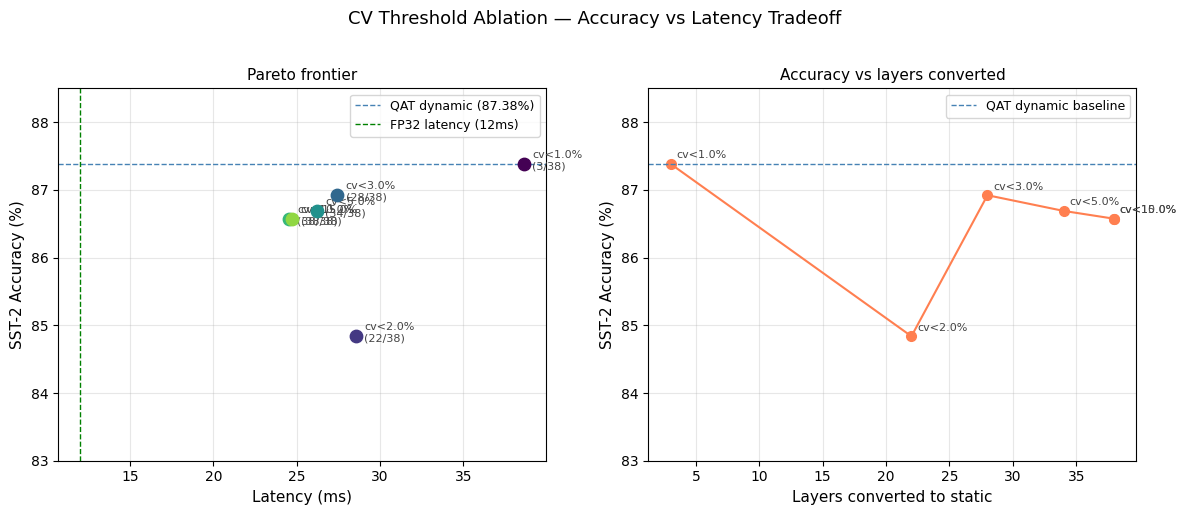

Saved to results/figures/


In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json

with open(f'{SAVE_DIR}/profiles/threshold_ablation.json') as f:
    results = json.load(f)

thresholds = [r['threshold'] for r in results]
accuracies = [r['accuracy']  for r in results]
latencies  = [r['latency']   for r in results]
converted  = [r['converted'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('CV Threshold Ablation — Accuracy vs Latency Tradeoff',
             fontsize=13, fontweight='normal', y=1.02)

# ── Left: Pareto curve (accuracy vs latency) ──
colors = plt.cm.viridis([i/len(results) for i in range(len(results))])
for i, r in enumerate(results):
    ax1.scatter(r['latency'], r['accuracy'],
                color=colors[i], s=80, zorder=5)
    ax1.annotate(f"cv<{r['threshold']}%\n({r['converted']}/38)",
                 (r['latency'], r['accuracy']),
                 textcoords='offset points', xytext=(6, -4),
                 fontsize=8, color='#444')

# reference lines
ax1.axhline(87.38, color='steelblue', linestyle='--',
            linewidth=1, label='QAT dynamic (87.38%)')
ax1.axvline(12.0,  color='green',     linestyle='--',
            linewidth=1, label='FP32 latency (12ms)')

ax1.set_xlabel('Latency (ms)', fontsize=11)
ax1.set_ylabel('SST-2 Accuracy (%)', fontsize=11)
ax1.set_title('Pareto frontier', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(83, 88.5)
ax1.grid(True, alpha=0.3)

# ── Right: layers converted vs accuracy ──
ax2.plot(converted, accuracies, 'o-', color='coral',
         linewidth=1.5, markersize=7)
for i, r in enumerate(results):
    ax2.annotate(f"cv<{r['threshold']}%",
                 (r['converted'], r['accuracy']),
                 textcoords='offset points', xytext=(4, 4),
                 fontsize=8, color='#444')

ax2.axhline(87.38, color='steelblue', linestyle='--',
            linewidth=1, label='QAT dynamic baseline')
ax2.set_xlabel('Layers converted to static', fontsize=11)
ax2.set_ylabel('SST-2 Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy vs layers converted', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_ylim(83, 88.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/fig4_threshold_ablation.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(f'{SAVE_DIR}/figures/fig4_threshold_ablation.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved to results/figures/")